# Solución - Tarea 1 - pregunta 1 - DMLA


## Pregunta 1.a - Clasificador k-NN

Se utiliza el dataset `MNIST` disponible en `sklearn.datasets` para entrenar un clasificador k-NN. A continuación se cargan los datos, se aplica preprocesamiento básico y se entrena el modelo con `k=5`.


In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Cargar datos
digits = load_digits()
X = digits.data
y = digits.target

# División entrenamiento/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluación
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9861111111111112
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



## Pregunta 1.b - Visualización con t-SNE

Usamos t-SNE para reducir el espacio de características a 2 dimensiones y visualizar la distribución de las clases. Esto permite observar si existen clusters visualmente separables.


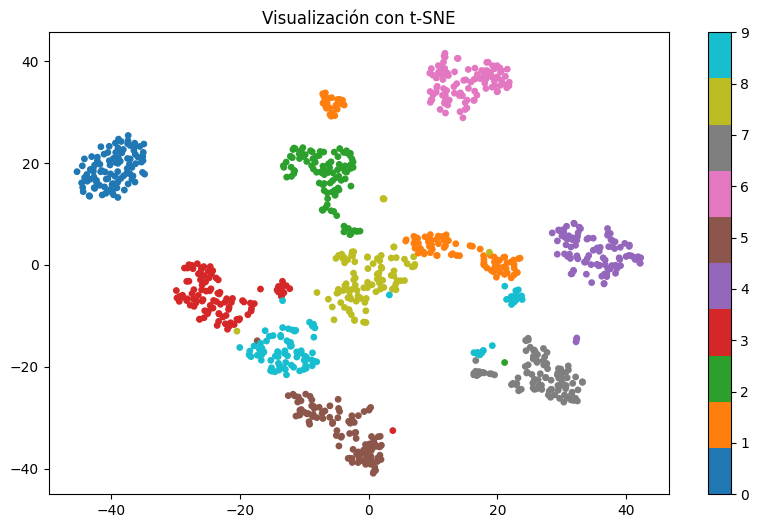

In [2]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X[:1000])  # reducir por tiempo

# Visualizar
plt.figure(figsize=(10,6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y[:1000], cmap='tab10', s=15)
plt.colorbar()
plt.title("Visualización con t-SNE")
plt.show()

## Pregunta 1.c - Pruebas con distintas configuraciones

Probamos el modelo k-NN con diferentes valores de `k` y métricas de distancia (`euclidean`, `manhattan`) para analizar el impacto en el rendimiento.


In [3]:
metrics = ['euclidean', 'manhattan']
for metric in metrics:
    for k in [3, 5, 7]:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        print(f"Metric: {metric}, k: {k}, Accuracy: {acc:.4f}")

Metric: euclidean, k: 3, Accuracy: 0.9833
Metric: euclidean, k: 5, Accuracy: 0.9861
Metric: euclidean, k: 7, Accuracy: 0.9889
Metric: manhattan, k: 3, Accuracy: 0.9778
Metric: manhattan, k: 5, Accuracy: 0.9806
Metric: manhattan, k: 7, Accuracy: 0.9750
